## 1. What this notebook computes

In the Kohn-Sham model of dirac16complex in the deflating primordial field every
orbital is described by a pair of functions $\chi = (\chi_1, \chi_2)$ of the
hidden coordinate $y$ between the tip cutoff $y = -L$ and the brane $y = 0$. This
notebook studies the simplest case completely: no interaction ($v = 0$, constant
mass $M$) and zero 3-momentum ($k = 0$). It

- writes the $2\times2$ block equation in real form and checks it;
- derives and checks the boundary conditions: the Z2 mirror brane at $y = 0$
  (ASSUMED) with its two parities, the regular tip at $y = -L$ (a CHOSEN cutoff
  condition), and what they imply (no current through the ends, real levels);
- solves the equation exactly: the brane zero mode $\varepsilon = 0$, the even
  levels $\pm\sqrt{M^2 + (n\pi/L)^2}$ and the odd levels from
  $\tan(pL) = -p/M$ (figure 1);
- solves it again numerically with the method of the Revision Rust solver:
  fourth-order Runge-Kutta (RK4) shooting with a Pruefer angle that gives every
  level an integer label (figures 2 and 6);
- compares the two for 54 levels and reproduces the Rust solver's record to
  about $10^{-14}$ (figure 3);
- measures the fourth-order convergence of the method (figure 4) and draws the
  orbitals against the exact ones (figure 5).

It prints a PASS line for every check (20 in all) and saves six figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 14b (The free Kohn-Sham spectrum at zero 3-momentum: exact formulas against
numerical shooting) is the file `Revision/textbook/notebooks/14b_free_spectra.ipynb` of
the repository Dirac_claude. For the free field (no interaction, constant mass M, zero
3-momentum) it writes the 2 x 2 block equation of dirac16complex in real form, derives
its boundary conditions (the ASSUMED Z2 mirror brane at y = 0 and the regular tip at y =
-L) and their consequences, solves the equation exactly (the brane zero mode, the even
levels plus or minus the square root of M^2 + (n pi/L)^2, the odd levels from tan(pL) =
-p/M), solves it again numerically with a fourth-order Runge-Kutta shooting method whose
Pruefer angle gives every level an integer label, and compares the two: it reproduces the
free spectra, the zero mode and the measured fourth-order convergence of the Revision
Rust solver and draws six teaching figures. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 14b_free_spectra.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 40 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 14b_free_spectra.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
14b_free_spectra.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/14b.captions.json`
- `Revision/textbook/figures/14b_1_odd_condition.png`
- `Revision/textbook/figures/14b_2_shooting_function.png`
- `Revision/textbook/figures/14b_3_spectrum_ladder.png`
- `Revision/textbook/figures/14b_4_rk4_convergence.png`
- `Revision/textbook/figures/14b_5_orbitals.png`
- `Revision/textbook/figures/14b_6_pruefer_angle.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files of this notebook exist
    ALL 20 CHECKS PASSED (notebook 14b)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/14b_free_spectra.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- the cells of sections 9 and 10 run for 10 to 20 seconds each: they integrate the
  equation for hundreds of energies at once, 72 times over; wait until the PASS lines
  appear.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 14b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 14b (The free Kohn-Sham spectrum at zero 3-momentum: exact formulas against
# numerical shooting) is the file Revision/textbook/notebooks/14b_free_spectra.ipynb of
# the repository Dirac_claude. For the free field (no interaction, constant mass M, zero
# 3-momentum) it writes the 2 x 2 block equation of dirac16complex in real form, derives
# its boundary conditions (the ASSUMED Z2 mirror brane at y = 0 and the regular tip at y
# = -L) and their consequences, solves the equation exactly (the brane zero mode, the
# even levels plus or minus the square root of M^2 + (n pi/L)^2, the odd levels from
# tan(pL) = -p/M), solves it again numerically with a fourth-order Runge-Kutta shooting
# method whose Pruefer angle gives every level an integer label, and compares the two: it
# reproduces the free spectra, the zero mode and the measured fourth-order convergence of
# the Revision Rust solver and draws six teaching figures. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 14b_free_spectra.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 40
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 14b_free_spectra.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 14b_free_spectra.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/14b.captions.json
# - Revision/textbook/figures/14b_1_odd_condition.png
# - Revision/textbook/figures/14b_2_shooting_function.png
# - Revision/textbook/figures/14b_3_spectrum_ladder.png
# - Revision/textbook/figures/14b_4_rk4_convergence.png
# - Revision/textbook/figures/14b_5_orbitals.png
# - Revision/textbook/figures/14b_6_pruefer_angle.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files of this notebook exist
#     ALL 20 CHECKS PASSED (notebook 14b)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/14b_free_spectra.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - the cells of sections 9 and 10 run for 10 to 20 seconds each: they integrate the
#   equation for hundreds of energies at once, 72 times over; wait until the PASS lines
#   appear.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "14b"  # this notebook: chapter 14, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 14b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Hidden coordinate $y$**: proper length along the hidden direction $x_8$;
  the brane is at $y = 0$, the tip cutoff at $y = -L$ (here $L = 3$, $2$).
- **Block equation**: in each of eight $2\times2$ blocks the Kohn-Sham
  equation is $h_j\chi = \varepsilon\chi$ with
  $h_j = j[-i\sigma_1\,d/dy + M\sigma_2 + \kappa k\,\sigma_3] + v$, where
  $j = \pm1$ is the block type, $M$ the (effective) mass, $\kappa k$ the
  weighted 3-momentum and $v$ the vector potential.
- **Level, orbital**: an energy $\varepsilon$ for which a solution exists that
  satisfies both boundary conditions; that solution is the orbital.
- **Real form**: writing $\chi = (a, ib)$ with real $a$, $b$ makes all
  coefficients real.
- **Boundary condition**: a condition on the solution at an end of the interval.
- **Z2 mirror brane**: the ASSUMED picture that the patch $y \le 0$ is glued at
  $y = 0$ to a mirror copy; it gives the even parity ($b(0) = 0$) and the odd
  parity ($a(0) = 0$).
- **Regular tip**: the chosen condition $b(-L) = 0$ at the cutoff.
- **Current**: $\chi^\dagger\sigma_1\chi$, the flow of the U(1) charge along
  $y$; a good boundary condition makes it vanish at the ends.
- **Self-adjoint**: the Hamiltonian satisfies $\int\varphi^\dagger h\chi\,dy =
  \int(h\varphi)^\dagger\chi\,dy$; then the levels are real.
- **Shooting**: start the solution at one end with the condition there,
  integrate to the other end, and adjust $\varepsilon$ until the condition there
  holds too.
- **RK4**: the classical fourth-order Runge-Kutta method for $u' = f(y, u)$ with
  step $h$: four slopes per step, error per unit length proportional to $h^4$.
- **Pruefer angle** $\theta = \mathrm{atan2}(b, a)$: the angle of the point
  $(a, b)$ in the plane; counting its half-turns labels the levels.
- **Bisection**: halve an interval that contains a root, keep the half where the
  function changes sign, repeat.
- **Simpson's rule**: an integration rule with the weights $1, 4, 2, 4, \dots,
  4, 1$ times (step/3).

## 4. The physical and mathematical situation

The Revision theory (`Revision/kohn_sham/ks-theory.json`) reduces the Kohn-Sham
equation exactly to the block equation $h_j\chi = \varepsilon\chi$ above, with
$\kappa(y) = e^{-Hy - a_{4,0}}$ at the slice $a_{4,0}$ of the deflating history.
In this notebook $k = 0$, so $\kappa$ drops out and the slice does not matter;
$v = 0$ and $M$ is a constant. The equation is then simple enough to solve by
hand, and these exact solutions are the first test of every numerical solver of
the model: the Revision Rust solver checked itself against them (its record
`Revision/kohn_sham/results/spectrum/free-k0-analytic.csv`). Here we write the
same numerical method with numpy, so that every step can be read, and we check
that it gives the same numbers.

Units: $H = 1$ and energies in units of the mass $m$ (the canonical runs use
$m = 1$, $L = 3$); the cases $(m, L) = (1, 2)$ and $(2, 3)$ test other values.

Status: the exact solutions are PROVED (and verified in the Revision record);
the numerical levels are COMPUTED (error measured against the exact ones); the
brane condition is ASSUMED; the tip condition is a chosen cutoff condition.

## 5. The block equation in real form

The eigenvalue equation $h_j\chi = \varepsilon\chi$ is the same as the
first-order system (Revision record, `blockEquation.ode`)

$$\chi' = N\chi,\qquad N = M\sigma_3 - \kappa k\,\sigma_2 + ij(\varepsilon - v)
\sigma_1 .$$

Write $\chi = (a, ib)$ with real functions $a$, $b$ and $K = \kappa k$. Then,
multiplying out the Pauli matrices:

$$a' = Ma - (K + j(\varepsilon - v))\,b,\qquad b' = (j(\varepsilon - v) - K)\,a
- Mb .$$

All coefficients are real, so a real starting point gives a real solution. The
next cell lets sympy multiply $N$ with $(a, ib)$ and checks that the result is
$(a', ib')$ with the two lines above.

In [2]:
import math  # exp, cos, sin of single numbers

import numpy as np  # floating-point arrays
import sympy as sp  # exact algebra with symbols

PY_REPORT = "Revision/kohn_sham/reports/ks-theory-python.json"
WL_REPORT = "Revision/kohn_sham/reports/ks-theory-wolfram.json"
RUST_REPORT = "Revision/kohn_sham/reports/ks-rust-solver.json"


def record_check(name, reports=(PY_REPORT, WL_REPORT)):
    """True when the check called name is PASS in the first report and, if the
    other reports have a check of that name, PASS there too."""
    verdicts = []
    for report in reports:
        data = json.loads(repository_file(report).read_text(encoding="utf-8"))
        found = [c["verdict"] for c in data["checks"] if c["name"] == name]
        verdicts.append(found[0] if found else "absent")
    return verdicts[0] == "PASS" and all(v in ("PASS", "absent") for v in verdicts)


s1 = sp.Matrix([[0, 1], [1, 0]])  # the Pauli matrices
s2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
s3 = sp.Matrix([[1, 0], [0, -1]])
I2 = sp.eye(2)
a, b, M, K, e, v = sp.symbols("a b M K epsilon v", real=True)
ok_all = True
for j in (1, -1):
    N = M * s3 - K * s2 + sp.I * j * (e - v) * s1  # the matrix of chi' = N chi
    derivative = sp.expand(N * sp.Matrix([a, sp.I * b]))  # N times (a, i b)
    a_prime = M * a - (K + j * (e - v)) * b  # the real form
    b_prime = (j * (e - v) - K) * a - M * b
    ok = (sp.expand(derivative[0] - a_prime) == 0
          and sp.expand(derivative[1] - sp.I * b_prime) == 0)
    ok_all &= ok
    say(f"j = {j:+d}: d chi/dy = N chi with chi = (a, i b) gives the real form: "
        f"{ok}")
theory = json.loads(repository_file("Revision/kohn_sham/ks-theory.json")
                    .read_text(encoding="utf-8"))
say("record: " + theory["blockEquation"]["realForm"])
check(ok_all, "the real form da/dy = M a - (K + j(eps - v)) b, "
      "db/dy = (j(eps - v) - K) a - M b")

j = +1: d chi/dy = N chi with chi = (a, i b) gives the real form: True
j = -1: d chi/dy = N chi with chi = (a, i b) gives the real form: True
record: chi = (a, i b), a, b real: a' = M_eff a - (kappa k + j(eps - v_v)) b, b' = (j(eps
    - v_v) - kappa k) a - M_eff b
PASS the real form da/dy = M a - (K + j(eps - v)) b, db/dy = (j(eps - v) - K) a - M b


## 6. The boundary conditions

**The brane (ASSUMED).** The Revision theory glues the patch $y \le 0$ at
$y = 0$ to a mirror copy (a Z2 orbifold, with the mirror warp $e^{-H|y|}$) and
asks $\Psi(-y) = \pm\gamma^{(x_8)}\Psi(y)$. At $y = 0$ this says
$(1 \mp \gamma^{(x_8)})\chi(0) = 0$; since $\gamma^{(x_8)} = \sigma_3$ in every
block: EVEN parity $\chi_2(0) = 0$, i.e. $b(0) = 0$; ODD parity $\chi_1(0) = 0$,
i.e. $a(0) = 0$. Line by line, what the mirror map does: if $\chi$ solves
$\chi'(y) = N(y)\chi(y)$, then $\tilde\chi(y) = \sigma_3\chi(-y)$ has
$\tilde\chi'(y) = -\sigma_3N(-y)\sigma_3\tilde\chi(y)$, and with
$\sigma_3\sigma_{1,2}\sigma_3 = -\sigma_{1,2}$ this is the same equation with the
mass $-M(-y)$, the potential $v(-y)$ and the weight $\kappa(-y)$. So the doubled
problem is mirror-symmetric only if the mass is ODD across the brane: the mirror
copy carries $-m$ (with the same $\lambda$), the $(+m, -m)$ mirror pair of the
pairing theorem T3. Under the map, $\chi^\dagger\chi$ and
$\chi^\dagger\sigma_3\chi$ are even, $\chi^\dagger\sigma_2\chi$ and the current
$\chi^\dagger\sigma_1\chi$ odd.

**The tip (chosen).** At the cutoff $y = -L$ the family $(1 - Q(\theta))\chi(-L)
= 0$ with $Q = \cos\theta\,\sigma_3 + \sin\theta\,\sigma_2$ is allowed;
$Q^\dagger = Q$, $Q^2 = 1$ and $Q\sigma_1 + \sigma_1Q = 0$, so every member
kills the current. The canonical choice is $\theta = 0$: $b(-L) = 0$.

**Why these conditions.** Integrating by parts, $\varphi^\dagger h_j\chi -
(h_j\varphi)^\dagger\chi = \frac{d}{dy}[-ij\,\varphi^\dagger\sigma_1\chi]$; if
both ends kill the current, the boundary terms vanish and $h_j$ is
self-adjoint: the levels are real and orbitals of different levels are
orthogonal. Moreover $\chi^\dagger\sigma_1\chi$ is constant in $y$ on every
solution ($N^\dagger\sigma_1 + \sigma_1N = 0$), while $\chi^\dagger\chi$ is not.

The next cell checks all of this with sympy, as the Revision record did.

In [3]:
y = sp.symbols("y", real=True)
H, a0, k = sp.symbols("H a0 k", real=True)
Mf = sp.Function("M", real=True)(y)  # a mass that depends on y
vf = sp.Function("v", real=True)(y)  # a potential that depends on y
kap = sp.exp(-H * y - a0)  # the momentum weight kappa(y)


def N_of(j, M_, v_, kap_):
    return M_ * s3 - kap_ * k * s2 + sp.I * j * (e - v_) * s1


ok_mirror = True
for j in (1, -1):  # chi~(y) = s3 chi(-y) solves chi~' = -s3 N(-y) s3 chi~
    mirrored = -s3 * N_of(j, Mf.subs(y, -y), vf.subs(y, -y), kap.subs(y, -y)) * s3
    target = N_of(j, -Mf.subs(y, -y), vf.subs(y, -y), kap.subs(y, -y))
    ok_mirror &= sp.simplify(mirrored - target).is_zero_matrix
check(ok_mirror and record_check("bc_mirror_map_PA"),
      "the mirror map chi(y) -> sigma3 chi(-y) turns M(y) into -M(-y)",
      record=f"{PY_REPORT}, check bc_mirror_map_PA")
even = {name: (s3 * X * s3 - X).is_zero_matrix
        for name, X in {"n": I2, "S": s2, "Q": s3, "current": s1}.items()}
say(f"even under the mirror map: {even}")
check(even == {"n": True, "S": False, "Q": True, "current": False}
      and record_check("bc_mirror_parities_of_densities"),
      "n and Q are even, S and the current odd: the mirror copy carries -m",
      record=f"{PY_REPORT}, check bc_mirror_parities_of_densities")
c1f, c2f = sp.Function("chi1")(y), sp.Function("chi2")(y)
current = sp.expand((sp.Matrix([c1f, c2f]).H * s1 * sp.Matrix([c1f, c2f]))[0])
check(current.subs(c2f, 0) == 0 and current.subs(c1f, 0) == 0
      and record_check("bc_brane_parity_conditions"),
      "both brane parities (chi2(0) = 0 or chi1(0) = 0) kill the current",
      record=f"{PY_REPORT}, check bc_brane_parity_conditions")
phi = sp.Matrix([sp.Function("phi1")(y), sp.Function("phi2")(y)])
chi = sp.Matrix([c1f, c2f])
ok_adjoint = True
for j in (1, -1):
    def h_on(w, j=j):  # h_j applied to the column w
        return j * (-sp.I * s1 * sp.diff(w, y) + Mf * s2 * w + kap * k * s3 * w) \
            + vf * w
    difference = (phi.H * h_on(chi))[0] - (h_on(phi).H * chi)[0]
    boundary = sp.diff(-sp.I * j * (phi.H * s1 * chi)[0], y)
    ok_adjoint &= sp.simplify(sp.expand(difference - boundary)) == 0
check(ok_adjoint and record_check("bc_self_adjoint_boundary_term"),
      "phi^dag h chi - (h phi)^dag chi = d/dy[-i j phi^dag sigma1 chi]",
      record=f"{PY_REPORT}, check bc_self_adjoint_boundary_term")
th = sp.symbols("theta", real=True)
Q = sp.cos(th) * s3 + sp.sin(th) * s2  # the tip family
check(sp.simplify(Q * Q - I2).is_zero_matrix and Q.H == Q
      and sp.simplify(Q * s1 + s1 * Q).is_zero_matrix and record_check("bc_tip_family"),
      "the tip family Q(theta): Q^dag = Q, Q^2 = 1, Q sigma1 = -sigma1 Q",
      record=f"{PY_REPORT}, check bc_tip_family")
kp = sp.symbols("kappa", positive=True)
ok_current = True
for j in (1, -1):
    Nn = M * s3 - kp * k * s2 + sp.I * j * (e - v) * s1
    ok_current &= sp.simplify(Nn.H * s1 + s1 * Nn).is_zero_matrix
    density_changes = not sp.simplify(Nn.H + Nn).is_zero_matrix
check(ok_current and density_changes and record_check("bc_current_conserved_along_y"),
      "the current is constant along y on every solution, the density is not",
      record=f"{PY_REPORT}, check bc_current_conserved_along_y")

PASS the mirror map chi(y) -> sigma3 chi(-y) turns M(y) into -M(-y)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check bc_mirror_map_PA
even under the mirror map: {'n': True, 'S': False, 'Q': True, 'current': False}
PASS n and Q are even, S and the current odd: the mirror copy carries -m
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    bc_mirror_parities_of_densities
PASS both brane parities (chi2(0) = 0 or chi1(0) = 0) kill the current
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    bc_brane_parity_conditions
PASS phi^dag h chi - (h phi)^dag chi = d/dy[-i j phi^dag sigma1 chi]
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    bc_self_adjoint_boundary_term
PASS the tip family Q(theta): Q^dag = Q, Q^2 = 1, Q sigma1 = -sigma1 Q
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check bc_tip_family
PASS the current is constant along y on every solution, the density is not
 

## 7. The exact solutions at zero 3-momentum

Take $k = 0$, $v = 0$ and a constant $M > 0$. The real form becomes
$a' = Ma - j\varepsilon b$, $b' = j\varepsilon a - Mb$. Line by line:

1. If $\varepsilon \ne 0$, solve the second equation for $a$:
   $a = (b' + Mb)/(j\varepsilon)$.
2. Differentiate: $a' = (b'' + Mb')/(j\varepsilon)$.
3. Put 1 and 2 into the first equation and multiply by $j\varepsilon$ (with
   $j^2 = 1$): $b'' + Mb' = M(b' + Mb) - \varepsilon^2 b$, that is
   $b'' = (M^2 - \varepsilon^2)\,b$.
4. EVEN parity, $b(0) = 0$ and $b(-L) = 0$: a solution that vanishes at both
   ends needs $M^2 - \varepsilon^2 = -p^2 < 0$, $b = \sin(py)$, and
   $\sin(-pL) = 0$, so $p = n\pi/L$: $\varepsilon = \pm\sqrt{M^2 + (n\pi/L)^2}$,
   $n = 1, 2, \dots$
5. EVEN parity and $\varepsilon = 0$: the equations decouple, $a' = Ma$,
   $b' = -Mb$; $b = 0$ satisfies both conditions and $a = e^{My}$: the BRANE
   ZERO MODE, largest at the brane, for every $L$.
6. ODD parity, $a(0) = 0$ and $b(-L) = 0$: $b = \sin(p(y + L))$ and, by 1,
   $a(0) = 0$ means $b'(0) + Mb(0) = 0$, i.e. $p\cos(pL) + M\sin(pL) = 0$, or
   $\tan(pL) = -p/M$; then $\varepsilon = \pm\sqrt{M^2 + p^2}$. In each interval
   $(n + \frac12)\pi/L < p < (n + 1)\pi/L$ there is exactly one root $p_n$.

Every level holds 4 states per block type (the four blocks of the same $j$),
8 in all. The next cell verifies 4 to 6 with sympy and computes the exact levels
for the labels $-3, \dots, 5$ of both parities and the three cases
$(m, L) = (1, 3), (1, 2), (2, 3)$, in the label convention of the Rust solver
(even: label 0 the zero mode, label $n > 0$ the $n$-th positive level, $-n$ its
negative; odd: label $l \ge 0$ the root $p_l$ with the plus sign, label
$l \le -1$ the root $p_{-l-1}$ with the minus sign). The odd roots are found by
bisection in their intervals, as the Rust solver does. The exact levels must
equal the column `eps_analytic` of the Rust solver's record.

In [4]:
Lc = sp.symbols("L", positive=True)
n_int = sp.symbols("n", integer=True, positive=True)
ok_exact = sp.simplify(sp.diff(sp.exp(M * y), y) - M * sp.exp(M * y)) == 0  # step 5
for j in (1, -1):  # step 4: b = sin(n pi y/L), a = (b' + M b)/(j eps)
    p_n = n_int * sp.pi / Lc
    eps_n = sp.sqrt(M ** 2 + p_n ** 2)
    b_n = sp.sin(p_n * y)
    a_n = (sp.diff(b_n, y) + M * b_n) / (j * eps_n)
    ok_exact &= sp.simplify(sp.diff(a_n, y) - (M * a_n - j * eps_n * b_n)) == 0
    ok_exact &= b_n.subs(y, 0) == 0 and sp.simplify(b_n.subs(y, -Lc)) == 0
p = sp.symbols("p", positive=True)  # step 6 (j = +1)
b_odd = sp.sin(p * (y + Lc))
eps_odd = sp.sqrt(M ** 2 + p ** 2)
a_odd = (sp.diff(b_odd, y) + M * b_odd) / eps_odd
ok_exact &= sp.simplify(sp.diff(a_odd, y) - (M * a_odd - eps_odd * b_odd)) == 0
ok_exact &= sp.simplify(a_odd.subs(y, 0) * eps_odd
                        - (p * sp.cos(p * Lc) + M * sp.sin(p * Lc))) == 0
check(ok_exact and record_check("bc_exact_k0_spectra"),
      "the zero mode, the even levels and the odd condition tan(pL) = -p/M",
      record=f"{PY_REPORT}, check bc_exact_k0_spectra")


def odd_roots(m, L, count):
    """The first count roots p of m sin(pL) + p cos(pL) = 0, by bisection."""
    roots = []
    for n in range(count):
        lo, hi = (n + 0.5) * math.pi / L, (n + 1.0) * math.pi / L
        f = lambda q: m * math.sin(q * L) + q * math.cos(q * L)
        f_lo = f(lo)
        for _ in range(200):
            mid = 0.5 * (lo + hi)
            if mid <= lo or mid >= hi:  # the interval cannot shrink any more
                break
            if (f(mid) > 0.0) == (f_lo > 0.0):
                lo = mid
            else:
                hi = mid
        roots.append(0.5 * (lo + hi))
    return roots


def exact_level(m, L, parity, label):
    """The exact k = 0 level with the given parity and label."""
    if parity == "even":
        if label == 0:
            return 0.0
        return math.copysign(math.sqrt(m * m + (label * math.pi / L) ** 2), label)
    roots = odd_roots(m, L, 6)
    if label >= 0:
        return math.sqrt(m * m + roots[label] ** 2)
    return -math.sqrt(m * m + roots[-label - 1] ** 2)


CASES = [(1.0, 3.0), (1.0, 2.0), (2.0, 3.0)]  # (m, L)
LABELS = list(range(-3, 6))  # the labels -3 ... 5
record_rows = repository_file(
    "Revision/kohn_sham/results/spectrum/free-k0-analytic.csv"
).read_text(encoding="utf-8").splitlines()
header = record_rows[0].split(",")
record = [dict(zip(header, row.split(","))) for row in record_rows[1:]]
exact = {}  # (m, L, parity, label) -> exact level
for m_, L_ in CASES:
    for label in LABELS:
        for parity in ("even", "odd"):
            exact[(m_, L_, parity, label)] = exact_level(m_, L_, parity, label)
worst = max(abs(exact[(float(r["m"]), float(r["L"]), r["parity"], int(r["label"]))]
                - float(r["eps_analytic"])) for r in record)
say(f"(m, L) = (1, 3): odd roots p = "
    + ", ".join(f"{q:.6f}" for q in odd_roots(1.0, 3.0, 3)) + ", ...")
lowest_odd = exact[(1.0, 3.0, "odd", 0)]  # the lowest odd level, m = 1, L = 3
lowest_even = exact[(1.0, 3.0, "even", 1)]  # the lowest positive even level
report("lowest odd level for m = 1, L = 3", f"{lowest_odd:.12f}", "m")
report("lowest positive even level for m = 1, L = 3", f"{lowest_even:.12f}", "m")
check(len(record) == 54 and worst < 1e-12,
      "the 54 exact levels equal the column eps_analytic of the record",
      record="Revision/kohn_sham/results/spectrum/free-k0-analytic.csv, eps_analytic")

PASS the zero mode, the even levels and the odd condition tan(pL) = -p/M
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    bc_exact_k0_spectra
(m, L) = (1, 3): odd roots p = 0.818548, 1.744313, 2.734844, ...
RESULT lowest odd level for m = 1, L = 3 = 1.292292828069 m
RESULT lowest positive even level for m = 1, L = 3 = 1.447971930402 m
PASS the 54 exact levels equal the column eps_analytic of the record
     reproduces Revision/kohn_sham/results/spectrum/free-k0-analytic.csv, eps_analytic


The next cell draws the odd condition for $m = 1$, $L = 3$: the function
$f(p) = M\sin(pL) + p\cos(pL)$ for $p$ from 0 to 7, with its roots $p_0, p_1,
\dots$ marked, and the intervals $((n + \frac12)\pi/L, (n+1)\pi/L)$ shaded in
which the bisection looks for them. Each root gives the level
$\sqrt{M^2 + p_n^2}$.

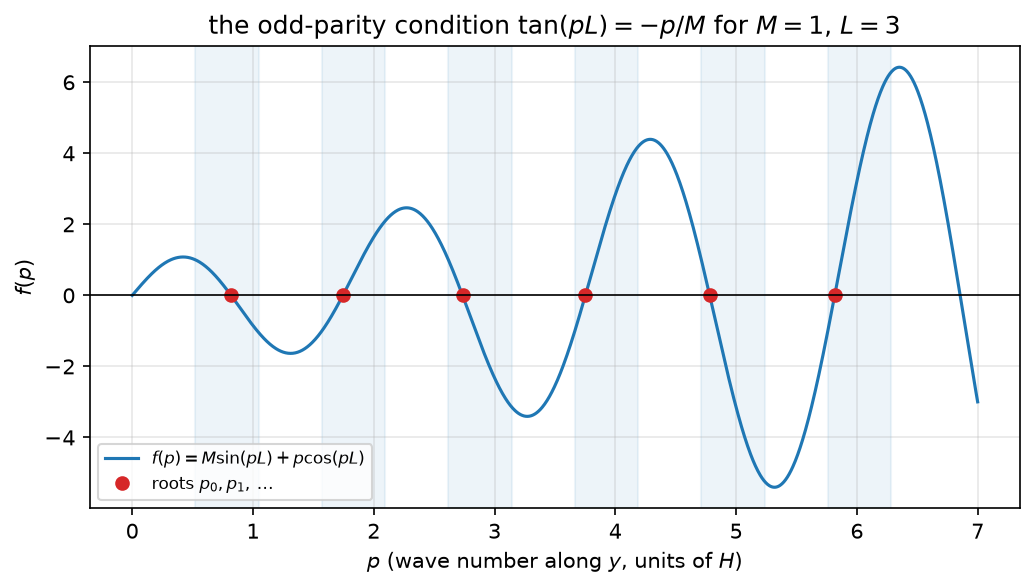

Figure 14b.1 saved as Revision/textbook/figures/14b_1_odd_condition.png


In [5]:
p_values = np.linspace(0.0, 7.0, 1401)
f_values = 1.0 * np.sin(3.0 * p_values) + p_values * np.cos(3.0 * p_values)
roots_13 = odd_roots(1.0, 3.0, 6)
fig, ax = plt.subplots(figsize=(8.0, 4.0))
for n in range(6):  # the intervals in which the roots lie
    ax.axvspan((n + 0.5) * math.pi / 3.0, (n + 1.0) * math.pi / 3.0, color="C0",
               alpha=0.08)
ax.plot(p_values, f_values, color="C0", label="$f(p) = M\\sin(pL) + p\\cos(pL)$")
ax.plot(roots_13, [0.0] * 6, "o", color="C3", label="roots $p_0, p_1, \\dots$")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("$p$ (wave number along $y$, units of $H$)")
ax.set_ylabel("$f(p)$")
ax.set_title("the odd-parity condition $\\tan(pL) = -p/M$ for $M = 1$, $L = 3$")
ax.legend(fontsize=8, loc="lower left")
save_figure(fig, "odd_condition",
            "The odd-parity level condition for $M = 1$ and $L = 3$: the function "
            "$f(p) = M\\sin(pL) + p\\cos(pL)$ against the wave number $p$ along $y$ "
            "(units of $H$); its zeros (red dots) are the solutions of "
            "$\\tan(pL) = -p/M$, one in each shaded interval from "
            "$(n + 1/2)\\pi/L$ to $(n + 1)\\pi/L$, and each gives the pair of "
            "levels $\\pm\\sqrt{M^2 + p^2}$; the first root $p_0 = 0.8185$ gives "
            "the lowest odd level $1.2923\\,m$.")

## 8. The shooting method and the Pruefer angle

Shooting: start at the tip with the tip condition, $(a, b) = (\cos\frac\theta2,
\sin\frac\theta2)$ (for the canonical $\theta = 0$ this is $(1, 0)$, so
$b(-L) = 0$), integrate the real form from $y = -L$ to $y = 0$ for a trial
energy $\varepsilon$, and look at the end point. The level is the energy for
which the brane condition holds.

To count, use the Pruefer angle $\theta(y) = \mathrm{atan2}(b, a)$, followed
continuously. Line by line:

1. $a = r\cos\theta$, $b = r\sin\theta$, so $\theta' = (ab' - ba')/r^2$.
2. Insert the real form: $ab' - ba' = j\varepsilon'(a^2 + b^2) - K(a^2 - b^2) -
   2Mab$ with $\varepsilon' = \varepsilon - v$.
3. With $a^2 - b^2 = r^2\cos2\theta$ and $2ab = r^2\sin2\theta$:
   $\theta' = j(\varepsilon - v) - K\cos2\theta - M\sin2\theta$.
4. The derivative of the end angle with respect to the energy is
   $d\theta(0)/d\varepsilon = j\int_{-L}^0 r^2\,dy\,/\,r(0)^2$; so
   $\Phi(\varepsilon) = j\,\theta(0)$ grows strictly with $\varepsilon$.

The brane condition says: even, $b(0) = 0$, i.e. $\Phi = l\pi$; odd, $a(0) = 0$,
i.e. $\Phi = \pi/2 + l\pi$, with an integer label $l$. Because $\Phi$ only grows,
each label has exactly one level, no level can be missed, and bisection on
$\Phi(\varepsilon) - $ target always finds it.

The next cell checks line 3 with sympy and defines the two numerical tools of
the notebook, written exactly as in the Rust solver: `shoot` (classical RK4 with
$G$ steps on $[-L, 0]$, the coefficients taken at the nodes and step midpoints
of a fine grid of $2G + 1$ points, the angle unwrapped after every step) and
`levels` (bisection, 72 halvings of the interval $[-20, 20]$, which reaches the
resolution of floating-point numbers). Both work on whole arrays of energies at
once (numpy), which makes them fast.

In [6]:
r_s, t_s = sp.symbols("r t", positive=True)  # polar coordinates of (a, b)
a_p = r_s * sp.cos(t_s)
b_p = r_s * sp.sin(t_s)
j_s = sp.symbols("j")
num = a_p * ((j_s * e - K) * a_p - M * b_p) - b_p * (M * a_p - (K + j_s * e) * b_p)
pruefer = j_s * e - K * sp.cos(2 * t_s) - M * sp.sin(2 * t_s)
check(sp.simplify(num / r_s ** 2 - pruefer) == 0,
      "d theta/dy = j(eps - v) - K cos 2theta - M sin 2theta")


def shoot(eps, k=0.0, j=1.0, M=1.0, L=3.0, G=900, H=1.0, a4=0.0, tip=0.0,
          keep=False):
    """Integrate the real form from the tip to the brane for the energies eps.

    eps, k, j may be arrays (numpy combines them element by element).  Returns
    Phi = j theta(0); with keep=True also theta, a and b at the G + 1 nodes."""
    eps, k, j = np.broadcast_arrays(np.asarray(eps, dtype=float),
                                    np.asarray(k, dtype=float),
                                    np.asarray(j, dtype=float))
    nf = 2 * G + 1  # the fine grid: nodes and step midpoints
    y_fine = -L * ((nf - 1 - np.arange(nf)) / (nf - 1))
    e_minus_Hy = np.exp(-H * y_fine)  # e^(-Hy) on the fine grid
    kk = k * np.exp(-a4)  # k e^(-a4,0): kappa k = kk e^(-Hy)
    h = L / G
    a_ = np.full(eps.shape, math.cos(0.5 * tip))  # the tip condition
    b_ = np.full(eps.shape, math.sin(0.5 * tip))
    theta = np.full(eps.shape, 0.5 * tip)
    raw = np.arctan2(b_, a_)
    je = j * eps
    path = [(theta, a_, b_)]
    for i in range(G):
        K0, K1, K2 = (kk * e_minus_Hy[2 * i], kk * e_minus_Hy[2 * i + 1],
                      kk * e_minus_Hy[2 * i + 2])  # K at y, y + h/2, y + h
        p1a, p1b = M * a_ - (K0 + je) * b_, (je - K0) * a_ - M * b_
        a2, b2 = a_ + 0.5 * h * p1a, b_ + 0.5 * h * p1b
        p2a, p2b = M * a2 - (K1 + je) * b2, (je - K1) * a2 - M * b2
        a3, b3 = a_ + 0.5 * h * p2a, b_ + 0.5 * h * p2b
        p3a, p3b = M * a3 - (K1 + je) * b3, (je - K1) * a3 - M * b3
        a4_, b4_ = a_ + h * p3a, b_ + h * p3b
        p4a, p4b = M * a4_ - (K2 + je) * b4_, (je - K2) * a4_ - M * b4_
        a_ = a_ + h / 6.0 * (p1a + 2.0 * p2a + 2.0 * p3a + p4a)
        b_ = b_ + h / 6.0 * (p1b + 2.0 * p2b + 2.0 * p3b + p4b)
        new = np.arctan2(b_, a_)
        step = new - raw  # the change of the angle, brought into (-pi, pi]
        step = np.where(step > np.pi, step - 2 * np.pi,
                        np.where(step <= -np.pi, step + 2 * np.pi, step))
        theta = theta + step
        raw = new
        if keep:
            path.append((theta, a_, b_))
    if keep:
        return j * theta, [np.array(q) for q in zip(*path)]
    return j * theta


def target(parity, label):
    """Phi of the level: l pi (even) or pi/2 + l pi (odd)."""
    offset = np.where(np.asarray(parity) == "even", 0.0, 0.5 * np.pi)
    return offset + np.asarray(label, dtype=float) * np.pi


def levels(k, j, parity, label, iterations=72, **options):
    """The levels with the given labels, by bisection on Phi(eps) - target."""
    k, j, parity, label = np.broadcast_arrays(
        np.asarray(k, dtype=float), np.asarray(j, dtype=float),
        np.asarray(parity), np.asarray(label))
    goal = target(parity, label)
    lo, hi = np.full(k.shape, -20.0), np.full(k.shape, 20.0)
    for _ in range(iterations):
        mid = 0.5 * (lo + hi)
        g = shoot(mid, k, j, **options) - goal
        lo = np.where(g <= 0.0, mid, lo)  # g = 0: an exact level
        hi = np.where(g >= 0.0, mid, hi)
    return 0.5 * (lo + hi)


say("defined: shoot(eps, k, j, M, L, G, ...) and levels(k, j, parity, label, ...)")

PASS d theta/dy = j(eps - v) - K cos 2theta - M sin 2theta
defined: shoot(eps, k, j, M, L, G, ...) and levels(k, j, parity, label, ...)


The next cell computes the shooting function $\Phi(\varepsilon)$ for $m = 1$,
$L = 3$, $k = 0$, $j = +1$ and 801 energies from $-4$ to $4$ at once, for both
parities, checks that it grows strictly (line 4 of the derivation), checks the
same for a nonzero momentum $k = 0.75$ and both block types (the test of the Rust
solver), and draws it with the targets $l\pi$ (even) and $\pi/2 + l\pi$ (odd):
every crossing of a curve with one of its targets is a level.

PASS Phi(eps) grows strictly with eps (k = 0 and k = 0.75, both block types)


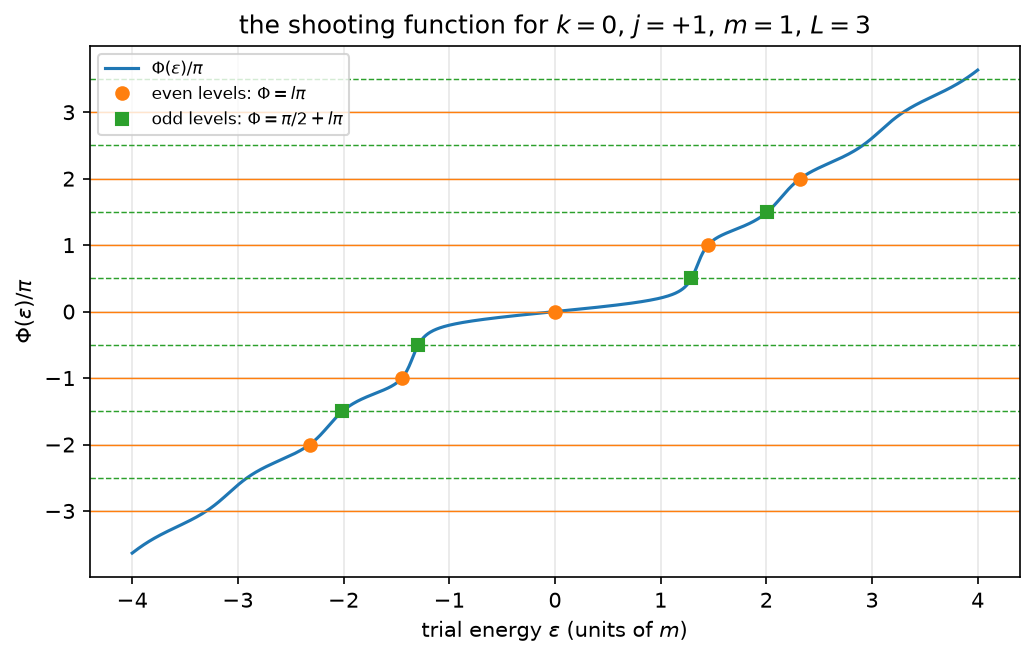

Figure 14b.2 saved as Revision/textbook/figures/14b_2_shooting_function.png


In [7]:
trial = np.linspace(-4.0, 4.0, 801)  # 801 trial energies
phi_curve = shoot(trial, 0.0, 1.0)  # Phi for k = 0, j = +1 (both parities)
grows = bool(np.all(np.diff(phi_curve) > 0.0))
grows_k = all(bool(np.all(np.diff(shoot(np.linspace(-4.0, 3.96, 200), 0.75, jj)) > 0))
              for jj in (1.0, -1.0))
check(grows and grows_k,
      "Phi(eps) grows strictly with eps (k = 0 and k = 0.75, both block types)")
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(trial, phi_curve / np.pi, color="C0", label="$\\Phi(\\varepsilon)/\\pi$")
for label in range(-3, 4):  # the targets in units of pi
    ax.axhline(label, color="C1", linewidth=0.7)
    ax.axhline(label + 0.5, color="C2", linewidth=0.7, linestyle="--")
even_levels = [exact[(1.0, 3.0, "even", l)] for l in range(-2, 3)]
odd_levels = [exact[(1.0, 3.0, "odd", l)] for l in range(-2, 2)]
ax.plot(even_levels, range(-2, 3), "o", color="C1",
        label="even levels: $\\Phi = l\\pi$")
ax.plot(odd_levels, [l + 0.5 for l in range(-2, 2)], "s", color="C2",
        label="odd levels: $\\Phi = \\pi/2 + l\\pi$")
ax.set_xlabel("trial energy $\\varepsilon$ (units of $m$)")
ax.set_ylabel("$\\Phi(\\varepsilon) / \\pi$")
ax.set_title("the shooting function for $k = 0$, $j = +1$, $m = 1$, $L = 3$")
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "shooting_function",
            "The shooting function $\\Phi(\\varepsilon) = j\\,\\theta(0)$ (the "
            "Pruefer angle at the brane, in units of $\\pi$) against the trial "
            "energy $\\varepsilon$ (units of $m$) for $k = 0$, $j = +1$, $m = 1$, "
            "$L = 3$. The solid horizontal lines are the even targets $l\\pi$, the "
            "dashed ones the odd targets $\\pi/2 + l\\pi$; the curve rises "
            "steadily, so it crosses every target exactly once, and the "
            "crossings are the exact levels (circles even, squares odd), "
            "including the zero mode at $\\varepsilon = 0$, $\\Phi = 0$; between "
            "$-1$ and $1$ the curve rises only a little, because no level lies "
            "there except the zero mode.")

## 9. All 54 levels: numerical against exact

The next cell computes the 54 levels (labels $-3$ to $5$, both parities, three
cases) by shooting and bisection, with the step numbers of the Rust solver:
$G = 900$ for $L = 3$ and $G = 600$ for $L = 2$ (the same step $h = 1/300$). It
checks three things:

- the numerical levels equal the Rust solver's column `eps_numeric` to
  $10^{-11}$ (the two programs do the same arithmetic; the differences are
  rounding, of order $10^{-14}$);
- the numerical error $|\varepsilon_{\rm num} - \varepsilon_{\rm exact}|$ is
  below $5\times10^{-9}$ for $|\varepsilon| < 4m$ and below $3.2\times10^{-7}$
  above, the tolerances of the Rust check `free_k0_analytic_spectra`;
- the zero mode comes out as exactly 0.

It prints the levels of the case $m = 1$, $L = 3$ next to the exact ones.

In [8]:
numeric = {}  # (m, L, parity, label) -> numerical level at the canonical step
for m_, L_ in CASES:
    pars = np.array([p_ for l_ in LABELS for p_ in ("even", "odd")])
    labs = np.array([l_ for l_ in LABELS for p_ in ("even", "odd")])
    found = levels(0.0, 1.0, pars, labs, M=m_, L=L_, G=round(900 * L_ / 3))
    for p_, l_, x in zip(pars, labs, found):
        numeric[(m_, L_, str(p_), int(l_))] = float(x)
say("m = 1, L = 3:  label  even (numerical)   even (exact)    "
    "odd (numerical)    odd (exact)")
for l_ in LABELS:
    row = [numeric[(1.0, 3.0, "even", l_)], exact[(1.0, 3.0, "even", l_)],
           numeric[(1.0, 3.0, "odd", l_)], exact[(1.0, 3.0, "odd", l_)]]
    say(f"               {l_:+d}   " + "  ".join(f"{x:15.10f}" for x in row))
rust_diff = max(abs(numeric[(float(r["m"]), float(r["L"]), r["parity"],
                             int(r["label"]))] - float(r["eps_numeric"]))
                for r in record)
check(rust_diff < 1e-11,
      "the 54 numerical levels equal those of the Rust solver",
      record="Revision/kohn_sham/results/spectrum/free-k0-analytic.csv, eps_numeric")
errors = {key: abs(numeric[key] - exact[key]) for key in numeric}
low = max(err for key, err in errors.items() if abs(exact[key]) < 4.0)
high = max(err for key, err in errors.items() if abs(exact[key]) >= 4.0)
check(low < 5e-9 and high < 3.2e-7 and record_check(
    "free_k0_analytic_spectra", (RUST_REPORT,)),
      "error below 5e-9 for |eps| < 4 m and below 3.2e-7 above",
      record=f"{RUST_REPORT}, check free_k0_analytic_spectra")
check(all(numeric[(m_, L_, "even", 0)] == 0.0 for m_, L_ in CASES),
      "the brane zero mode comes out as exactly eps = 0")

m = 1, L = 3:  label  even (numerical)   even (exact)    odd (numerical)    odd (exact)
               -3     -3.2969083098    -3.2969083095    -2.9119358755    -2.9119358754
               -2     -2.3208814802    -2.3208814802    -2.0106285601    -2.0106285600
               -1     -1.4479719304    -1.4479719304    -1.2922928281    -1.2922928281
               +0      0.0000000000     0.0000000000     1.2922928281     1.2922928281
               +1      1.4479719304     1.4479719304     2.0106285601     2.0106285600
               +2      2.3208814802     2.3208814802     2.9119358755     2.9119358754
               +3      3.2969083098     3.2969083095     3.8829900333     3.8829900326
               +4      4.3065024545     4.3065024532     4.8845756333     4.8845756308
               +5      5.3306254627     5.3306254587     5.9016800925     5.9016800858
PASS the 54 numerical levels equal those of the Rust solver
     reproduces Revision/kohn_sham/results/spectrum/free-k0-analytic.

The next cell draws the three spectra as level ladders: for each case
$(m, L)$ the exact levels as short horizontal lines and the numerical ones as
markers (even parity on the left of each ladder, odd on the right). The gap
$(-M, M)$ around zero contains only the zero mode; a larger $m$ widens it; a
shorter $L$ spreads the levels (the wave numbers $n\pi/L$ grow).

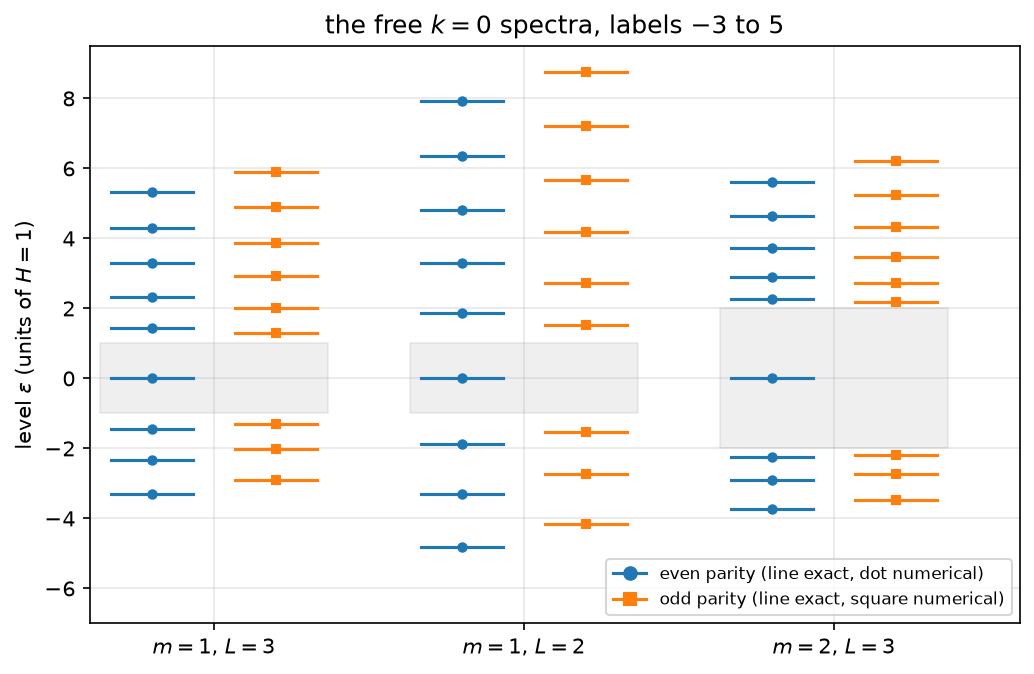

Figure 14b.3 saved as Revision/textbook/figures/14b_3_spectrum_ladder.png


In [9]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))
for position, (m_, L_) in enumerate(CASES):
    x0 = 3.0 * position  # the horizontal place of this ladder
    for l_ in LABELS:
        for shift, parity, color, marker in ((0.0, "even", "C0", "o"),
                                             (1.2, "odd", "C1", "s")):
            level = exact[(m_, L_, parity, l_)]
            ax.plot([x0 + shift - 0.4, x0 + shift + 0.4], [level, level],
                    color=color, linewidth=1.5)
            ax.plot([x0 + shift], [numeric[(m_, L_, parity, l_)]], marker,
                    color=color, markersize=4)
    ax.fill_between([x0 - 0.5, x0 + 1.7], -m_, m_, color="gray", alpha=0.12)
ax.set_xlim(-0.6, 8.4)
ax.set_ylim(-7.0, 9.5)
ax.set_xticks([0.6, 3.6, 6.6])
ax.set_xticklabels(["$m = 1$, $L = 3$", "$m = 1$, $L = 2$", "$m = 2$, $L = 3$"])
ax.plot([], [], "o-", color="C0", label="even parity (line exact, dot numerical)")
ax.plot([], [], "s-", color="C1", label="odd parity (line exact, square numerical)")
ax.set_ylabel("level $\\varepsilon$ (units of $H = 1$)")
ax.set_title("the free $k = 0$ spectra, labels $-3$ to $5$")
ax.legend(fontsize=8, loc="lower right")
save_figure(fig, "spectrum_ladder",
            "The free $k = 0$ spectra for the three cases $(m, L) = (1, 3)$, "
            "$(1, 2)$ and $(2, 3)$, labels $-3$ to $5$: exact levels as short "
            "horizontal lines, numerical RK4 levels as markers on them (even "
            "parity left, odd parity right of each ladder); vertical axis the "
            "level in units of $H = 1$. The shaded band from $-m$ to $m$ contains "
            "only the even zero mode at $0$; a larger mass widens the gap and a "
            "shorter interval $L$ spreads the levels; on this scale the numerical "
            "and the exact levels cannot be told apart.")

## 10. Fourth-order convergence

RK4 has an error proportional to $h^4$: halving the step should divide the error
of every level by $2^4 = 16$. The Rust solver's refined run (the record
`ks-rust-determinism.json`, check `refined_free_spectra_convergence_order`)
doubled the step number ($G = 1800$ for $L = 3$, $1200$ for $L = 2$) and found,
over the 39 levels whose canonical error exceeds $10^{-11}$, the median error
ratio 16.00, with the largest errors $5.050\times10^{-8}$ (canonical) and
$3.157\times10^{-9}$ (refined). The next cell repeats this measurement. It takes
about 15 seconds.

In [10]:
refined = {}
for m_, L_ in CASES:
    pars = np.array([p_ for l_ in LABELS for p_ in ("even", "odd")])
    labs = np.array([l_ for l_ in LABELS for p_ in ("even", "odd")])
    found = levels(0.0, 1.0, pars, labs, M=m_, L=L_, G=round(1800 * L_ / 3))
    for p_, l_, x in zip(pars, labs, found):
        refined[(m_, L_, str(p_), int(l_))] = float(x)
refined_errors = {key: abs(refined[key] - exact[key]) for key in refined}
ratios = sorted(errors[key] / refined_errors[key] for key in errors
                if errors[key] > 1e-11 and refined_errors[key] > 0.0)
median = ratios[len(ratios) // 2]
report("number of levels with a canonical error above 1e-11", len(ratios))
report("median error ratio canonical / refined", f"{median:.2f}")
report("largest error, canonical step", f"{max(errors.values()):.3e}", "m")
report("largest error, refined step", f"{max(refined_errors.values()):.3e}", "m")
check(len(ratios) == 39 and f"{median:.2f}" == "16.00"
      and f"{max(errors.values()):.3e}" == "5.050e-08"
      and f"{max(refined_errors.values()):.3e}" == "3.157e-09"
      and record_check("refined_free_spectra_convergence_order",
                       ("Revision/kohn_sham/reports/ks-rust-determinism.json",)),
      "39 levels, median error ratio 16.00, largest errors 5.050e-08 and 3.157e-09",
      record="Revision/kohn_sham/reports/ks-rust-determinism.json, check "
             "refined_free_spectra_convergence_order")

RESULT number of levels with a canonical error above 1e-11 = 39
RESULT median error ratio canonical / refined = 16.00
RESULT largest error, canonical step = 5.050e-08 m
RESULT largest error, refined step = 3.157e-09 m
PASS 39 levels, median error ratio 16.00, largest errors 5.050e-08 and 3.157e-09
     reproduces Revision/kohn_sham/reports/ks-rust-determinism.json, check
    refined_free_spectra_convergence_order


The next cell draws the convergence for four levels of the case $m = 1$,
$L = 3$ (even labels 1 and 3, odd labels 0 and 3), with the step numbers
$G = 150, 300, 600, 900, 1800$: the error against the step $h = L/G$ on
logarithmic axes, with a line of slope 4 for comparison.

PASS halving the step divides each error by about 16 (between 12 and 20)


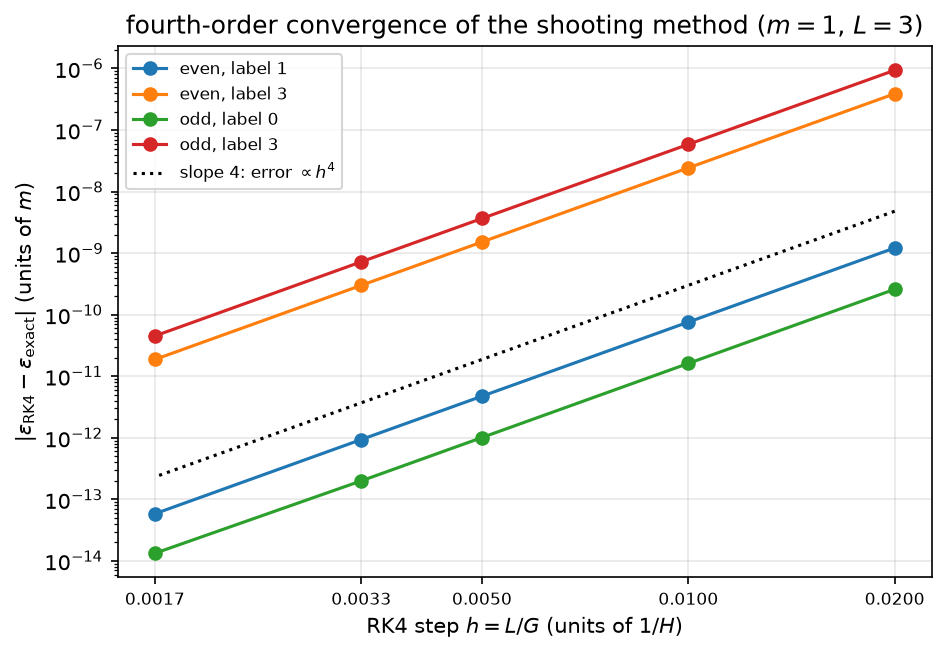

Figure 14b.4 saved as Revision/textbook/figures/14b_4_rk4_convergence.png


In [11]:
chosen = [("even", 1), ("even", 3), ("odd", 0), ("odd", 3)]
steps = [150, 300, 600, 900, 1800]
curves = {key: [] for key in chosen}
for G_ in steps:
    found = levels(0.0, 1.0, np.array([p_ for p_, l_ in chosen]),
                   np.array([l_ for p_, l_ in chosen]), M=1.0, L=3.0, G=G_)
    for key, x in zip(chosen, found):
        curves[key].append(abs(float(x) - exact[(1.0, 3.0) + key]))
h_values = np.array([3.0 / G_ for G_ in steps])
fig, ax = plt.subplots(figsize=(7.0, 4.6))
for (parity, label), errs in curves.items():
    ax.loglog(h_values, errs, "o-", label=f"{parity}, label {label}")
ax.loglog(h_values, 3e-2 * h_values ** 4, ":", color="black",
          label="slope 4: error $\\propto h^4$")
ax.set_xticks(h_values)  # one tick at each step used
ax.set_xticklabels([f"{x:.4f}" for x in h_values], fontsize=8)
ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())  # no extra ticks
ax.set_xlabel("RK4 step $h = L/G$ (units of $1/H$)")
ax.set_ylabel("$|\\varepsilon_{\\rm RK4} - \\varepsilon_{\\rm exact}|$ (units of $m$)")
ax.set_title("fourth-order convergence of the shooting method ($m = 1$, $L = 3$)")
ax.legend(fontsize=8)
fourth = all(12.0 < errs[i] / errs[i + 1] < 20.0 for errs in curves.values()
             for i in range(2))  # halving h from 0.02 to 0.005: ratios near 16
check(fourth, "halving the step divides each error by about 16 (between 12 and 20)")
save_figure(fig, "rk4_convergence",
            "The error of four numerical levels ($m = 1$, $L = 3$; even labels 1 "
            "and 3, odd labels 0 and 3) against the RK4 step $h = L/G$ for "
            "$G = 150, 300, 600, 900, 1800$, on logarithmic axes (both in units "
            "of $m = H = 1$). The points fall on lines parallel to the dotted line "
            "of slope 4: halving the step divides the error by 16, the order of "
            "the classical Runge-Kutta method; higher levels have larger errors "
            "because their orbitals oscillate faster.")

## 11. The orbitals

The orbital of a level is the solution $(a, b)$ itself, normalised so that
$\int_{-L}^0(a^2 + b^2)\,dy = 1$. The next cell defines `orbital`, again as in
the Rust solver: it keeps $(a, b)$ at the nodes, fills the step midpoints by
cubic Hermite interpolation (from the values and the derivatives at the two
neighbouring nodes, error of order $h^4$), and normalises with Simpson's rule on
the fine grid. It then checks the brane zero mode against the exact
$a = \sqrt{2M/(1 - e^{-2ML})}\,e^{My}$, $b = 0$ (the Rust check
`free_zero_mode_exact`: $\varepsilon = 0$ exactly, $b = 0$ exactly, $a$ to
$10^{-9}$), and the first even and odd orbitals against the exact ones of
section 7 (normalised the same way and with the sign that makes $a(-L) > 0$).

In [12]:
def orbital(eps, k=0.0, j=1.0, M=1.0, L=3.0, G=900, H=1.0, a4=0.0, tip=0.0):
    """The normalised orbital (y, a, b) on the fine grid of 2G + 1 points."""
    _, (theta_n, a_n, b_n) = shoot(eps, k, j, M=M, L=L, G=G, H=H, a4=a4, tip=tip,
                                   keep=True)
    nf, h = 2 * G + 1, L / G
    y_fine = -L * ((nf - 1 - np.arange(nf)) / (nf - 1))
    K_fine = k * np.exp(-a4) * np.exp(-H * y_fine)
    a_f, b_f = np.zeros(nf), np.zeros(nf)
    a_f[0::2], b_f[0::2] = a_n, b_n  # the node values
    da = M * a_f - (K_fine + j * eps) * b_f  # the derivatives at the nodes
    db = (j * eps - K_fine) * a_f - M * b_f
    for f in range(1, nf, 2):  # cubic Hermite value at each midpoint
        a_f[f] = 0.5 * (a_f[f - 1] + a_f[f + 1]) + h / 8.0 * (da[f - 1] - da[f + 1])
        b_f[f] = 0.5 * (b_f[f - 1] + b_f[f + 1]) + h / 8.0 * (db[f - 1] - db[f + 1])
    weights = np.full(nf, 2.0)  # Simpson: 1, 4, 2, 4, ..., 4, 1 times (h/2)/3
    weights[1::2] = 4.0
    weights[0] = weights[-1] = 1.0
    weights *= 0.5 * h / 3.0
    norm = math.sqrt(float(np.sum(weights * (a_f ** 2 + b_f ** 2))))
    return y_fine, a_f / norm, b_f / norm, weights


y_f, a_zero, b_zero, simpson = orbital(numeric[(1.0, 3.0, "even", 0)])
a_exact = math.sqrt(2.0 / (1.0 - math.exp(-6.0))) * np.exp(y_f)
deviation = float(np.max(np.abs(a_zero - a_exact)))
check(numeric[(1.0, 3.0, "even", 0)] == 0.0 and np.all(b_zero == 0.0)
      and deviation < 1e-9 and record_check("free_zero_mode_exact", (RUST_REPORT,)),
      "zero mode: eps = 0 and b = 0 exactly, a = sqrt(2M/(1 - e^(-2ML))) e^(My)",
      record=f"{RUST_REPORT}, check free_zero_mode_exact")


def exact_orbital(parity, label, m_=1.0, L_=3.0):
    """The exact orbital of section 7 (j = +1), normalised with Simpson."""
    level = exact[(m_, L_, parity, label)]
    p_ = math.sqrt(level ** 2 - m_ ** 2)
    if parity == "even":
        b_e = np.sin(p_ * y_f)
        a_e = (p_ * np.cos(p_ * y_f) + m_ * b_e) / level
    else:
        b_e = np.sin(p_ * (y_f + L_))
        a_e = (p_ * np.cos(p_ * (y_f + L_)) + m_ * b_e) / level
    sign = 1.0 if a_e[0] > 0 else -1.0  # the sign with a(-L) > 0
    norm = math.sqrt(float(np.sum(simpson * (a_e ** 2 + b_e ** 2))))
    return sign * a_e / norm, sign * b_e / norm


shown = {}
worst_orbital = 0.0
for parity, label in (("even", 1), ("odd", 0)):
    _, a_num, b_num, _ = orbital(numeric[(1.0, 3.0, parity, label)])
    a_ex, b_ex = exact_orbital(parity, label)
    worst_orbital = max(worst_orbital, float(np.max(np.abs(a_num - a_ex))),
                        float(np.max(np.abs(b_num - b_ex))))
    shown[(parity, label)] = (a_num, b_num, a_ex, b_ex)
check(worst_orbital < 1e-8,
      "the even label 1 and odd label 0 orbitals equal the exact ones to 1e-8")

PASS zero mode: eps = 0 and b = 0 exactly, a = sqrt(2M/(1 - e^(-2ML))) e^(My)
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_zero_mode_exact
PASS the even label 1 and odd label 0 orbitals equal the exact ones to 1e-8


The next cell draws the three orbitals of $m = 1$, $L = 3$: the zero mode
(largest at the brane, $b = 0$), the even level 1 and the odd level 0, each
with its two components $a$ (solid) and $b$ (dashed), and the exact curves as
dots on top.

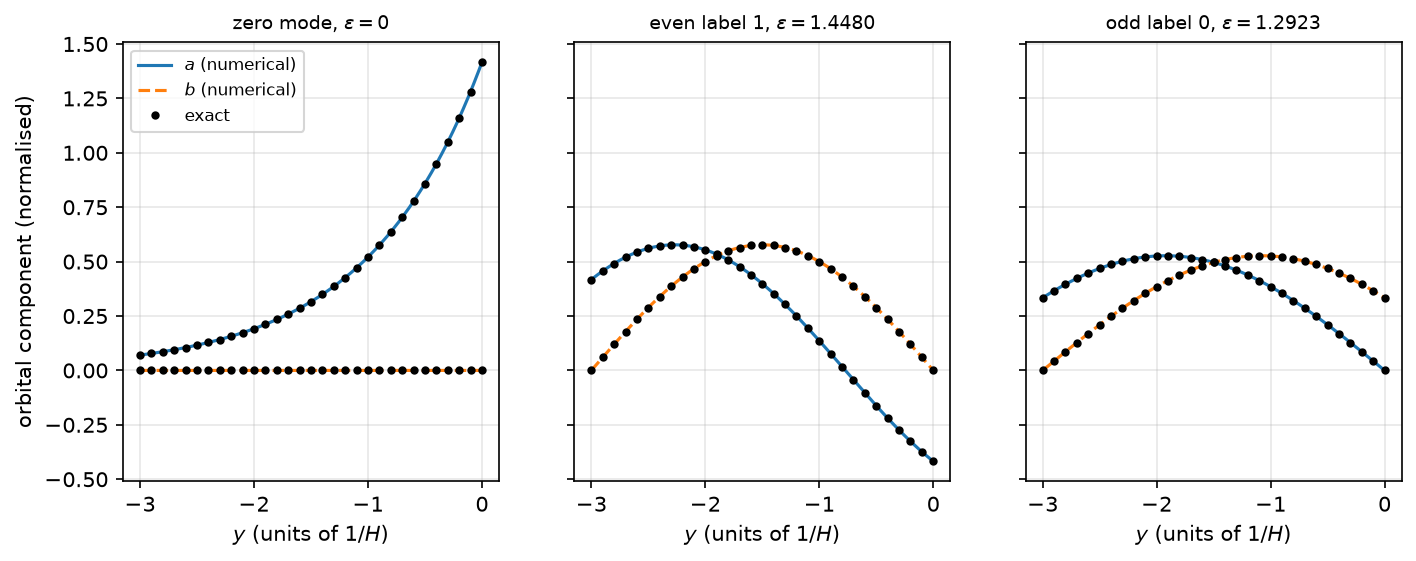

Figure 14b.5 saved as Revision/textbook/figures/14b_5_orbitals.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.8), sharey=True)
panels = [("zero mode, $\\varepsilon = 0$", a_zero, b_zero, a_exact,
           np.zeros_like(a_exact)),
          (f"even label 1, $\\varepsilon = {lowest_even:.4f}$",) + shown[("even", 1)],
          (f"odd label 0, $\\varepsilon = {lowest_odd:.4f}$",) + shown[("odd", 0)]]
for ax, (title, a_num, b_num, a_ex, b_ex) in zip(axes, panels):
    ax.plot(y_f, a_num, color="C0", label="$a$ (numerical)")
    ax.plot(y_f, b_num, "--", color="C1", label="$b$ (numerical)")
    ax.plot(y_f[::60], a_ex[::60], ".", color="black", label="exact")
    ax.plot(y_f[::60], b_ex[::60], ".", color="black")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("$y$ (units of $1/H$)")
axes[0].set_ylabel("orbital component (normalised)")
axes[0].legend(fontsize=8, loc="upper left")
save_figure(fig, "orbitals",
            "The normalised orbitals $\\chi = (a, ib)$ of three free $k = 0$ "
            "levels for $m = 1$, $L = 3$ against $y$ from the tip $-3$ to the "
            "brane $0$ (units of $1/H$): left the brane zero mode "
            "$a = \\sqrt{2/(1 - e^{-6})}\\,e^{y}$, $b = 0$, concentrated at the "
            "brane; middle the even level 1 with $b(0) = b(-3) = 0$; right the "
            "odd level 0 with $a(0) = 0$ and $b(-3) = 0$. Solid lines $a$, dashed "
            "lines $b$ from the RK4 shooting, black dots the exact solutions.")

The next cell draws how the Pruefer angle counts. For the even levels with the
labels 0 to 3 and the odd levels with the labels 0 to 2 ($m = 1$, $L = 3$,
$k = 0$, $j = +1$) it plots $\theta(y)/\pi$ along the hidden coordinate: every
curve starts at 0 at the tip and ends exactly on its target $l$ (even) or
$l + \frac12$ (odd) at the brane. The label is the number of half-turns the
point $(a, b)$ makes on its way.

PASS the Pruefer angle ends on its target l pi or (l + 1/2) pi for every level


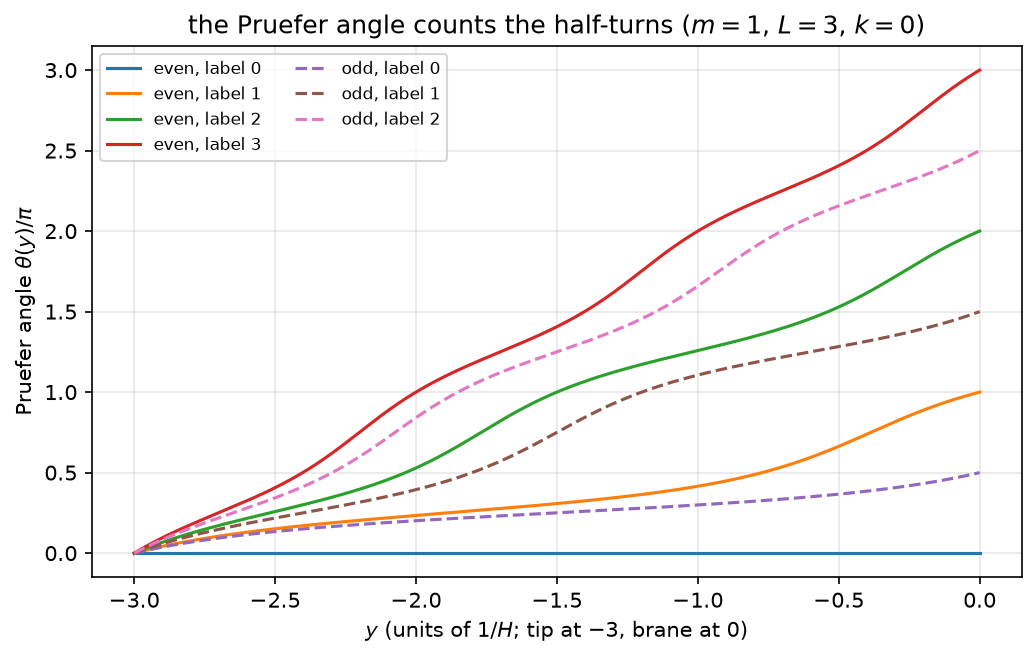

Figure 14b.6 saved as Revision/textbook/figures/14b_6_pruefer_angle.png


In [14]:
picks = [("even", l_) for l_ in range(4)] + [("odd", l_) for l_ in range(3)]
energies = np.array([numeric[(1.0, 3.0, p_, l_)] for p_, l_ in picks])
_, (theta_path, _, _) = shoot(energies, 0.0, 1.0, keep=True)
y_nodes = np.linspace(-3.0, 0.0, 901)
end_values = theta_path[-1] / np.pi
goals = np.array([l_ + (0.0 if p_ == "even" else 0.5) for p_, l_ in picks])
check(np.max(np.abs(end_values - goals)) < 1e-9,
      "the Pruefer angle ends on its target l pi or (l + 1/2) pi for every level")
fig, ax = plt.subplots(figsize=(8.0, 4.6))
for column, (p_, l_) in enumerate(picks):
    style = "-" if p_ == "even" else "--"
    ax.plot(y_nodes, theta_path[:, column] / np.pi, style,
            label=f"{p_}, label {l_}")
ax.set_xlabel("$y$ (units of $1/H$; tip at $-3$, brane at $0$)")
ax.set_ylabel("Pruefer angle $\\theta(y)/\\pi$")
ax.set_title("the Pruefer angle counts the half-turns ($m = 1$, $L = 3$, $k = 0$)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
save_figure(fig, "pruefer_angle",
            "The Pruefer angle $\\theta(y) = \\mathrm{atan2}(b, a)$ in units of "
            "$\\pi$ along the hidden coordinate $y$ (units of $1/H$) for the even "
            "levels with labels 0 to 3 (solid) and the odd levels with labels 0 "
            "to 2 (dashed), $m = 1$, $L = 3$, $k = 0$, $j = +1$. Every curve starts "
            "at $0$ at the tip (the condition $b(-3) = 0$) and ends exactly at its "
            "target at the brane, $l$ for even and $l + 1/2$ for odd parity; the "
            "zero mode stays at $0$ all the way.")

## 12. The last check

The last cell checks that the six figure files exist and prints the number of
checks that passed.

In [15]:
figure_names = ["14b_1_odd_condition.png", "14b_2_shooting_function.png",
                "14b_3_spectrum_ladder.png", "14b_4_rk4_convergence.png",
                "14b_5_orbitals.png", "14b_6_pruefer_angle.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all six figure files of this notebook exist")
all_checks_passed()

PASS all six figure files of this notebook exist
ALL 20 CHECKS PASSED (notebook 14b)


## 13. What this notebook showed

- The block equation of the Kohn-Sham model is real in the variables
  $\chi = (a, ib)$ (PROVED).
- The ASSUMED Z2 mirror brane gives the two parities $b(0) = 0$ and $a(0) = 0$;
  the mirror map turns the mass $M(y)$ into $-M(-y)$, so a mirror-symmetric
  doubled problem has the mass $-m$ in the mirror copy; the chosen regular tip
  gives $b(-L) = 0$; both ends kill the current and make $h_j$ self-adjoint
  (PROVED; reproduces the Revision checks).
- At $k = 0$ without interaction the levels are exactly $0$ (the brane zero mode
  $e^{My}$), $\pm\sqrt{M^2 + (n\pi/L)^2}$ (even) and $\pm\sqrt{M^2 + p^2}$ with
  $\tan(pL) = -p/M$ (odd); for $m = 1$, $L = 3$ the lowest positive levels are
  $1.2922928281\,m$ (odd) and $1.4479719304\,m$ (even) (PROVED).
- RK4 shooting with the Pruefer angle finds every level by its label; the 54
  numerical levels equal the Rust solver's to about $10^{-14}$, their errors are
  within the Rust tolerances, and halving the step divides the error by 16.00
  (median over 39 levels): the method is of fourth order (COMPUTED, error
  measured).
- The numerical orbitals equal the exact ones; the zero mode is exactly
  $\varepsilon = 0$, $b = 0$.